# Cuaderno 6 — Análisis corporativo profundo

**Tesis:** Predicción del Punto de Equilibrio de Flujo de Caja en Empresas de Crecimiento  
**Autores:** Andrea Meneses · Juan Ramos  
**Universidad EAFIT · 2026**

---

## Objetivo

Este cuaderno usa los valores SHAP del ensemble y el dataset completo — incluyendo empresas con FCF positivo — para responder preguntas de negocio concretas que van más allá de la métrica AUC-PR. El objetivo es transformar el modelo en conocimiento accionable sobre qué hace que una empresa de crecimiento alcance el punto de equilibrio de flujo de caja.

---

## Tres grupos de análisis

El análisis compara tres grupos de empresas-trimestre:

| Grupo | Definición | Tamaño |
|---|---|---|
| **A — FCF positivo** | Empresas que ya generan FCF operativo positivo | 39.976 trimestres |
| **B — Alcanza breakeven** | FCF negativo hoy, pero alcanza FCF positivo en los próximos 4 trimestres | 13.209 trimestres |
| **C — No alcanza breakeven** | FCF negativo hoy y sigue negativo en los próximos 4 trimestres | 14.173 trimestres |

---

## Estructura del cuaderno

1. **Perfil del ganador y el perdedor** — diferencias financieras entre los tres grupos
2. **Trayectorias hacia el breakeven** — cómo evolucionan las variables en los trimestres previos
3. **Análisis por sector** — qué sectores son más predecibles y cuáles más difíciles
4. **El rol del momentum** — cuánto aportan las features temporales
5. **El valor del retained earnings** — el umbral crítico de ganancias acumuladas
6. **Casos extremos** — cuando el modelo está muy seguro y cuando duda
7. **Errores del modelo** — qué empresas sorprendieron al modelo y por qué
8. **El camino típico al breakeven** — el perfil trimestre a trimestre de las empresas que llegan

## 1. Configuración inicial y carga de datos

In [1]:
import pandas as pd
import numpy as np
import pickle
import shap
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from sklearn.metrics import average_precision_score

warnings.filterwarnings("ignore")

# Identidad visual
juan_colors = ['#101B4B', '#545E85', '#A3A8B2', '#E7E7E7', '#0F19C9', '#F6D673']
FUENTE = "STIXGeneral"

def estilo_ax(ax, orientacion="vertical"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)
    if orientacion == "vertical":
        ax.spines["left"].set_visible(False)
        ax.yaxis.grid(True, linestyle="-", color=juan_colors[3], linewidth=0.8)
        ax.xaxis.grid(False)
    else:
        ax.spines["bottom"].set_visible(False)
        ax.xaxis.grid(True, linestyle="-", color=juan_colors[3], linewidth=0.8)
        ax.yaxis.grid(False)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FUENTE)

# Cargar modelos del ensemble
with open("../salidas/modelo_rf_final.pkl", "rb") as f:
    rf_final = pickle.load(f)
with open("../salidas/modelo_lgbm_final.pkl", "rb") as f:
    lgbm_final = pickle.load(f)

features_con_momentum = pd.read_csv("../salidas/features_modelo.csv").iloc[:, 0].tolist()

print(f"Modelos cargados: ensemble RF + LightGBM")
print(f"Features del modelo: {len(features_con_momentum)}")

/home/vscode/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Modelos cargados: ensemble RF + LightGBM
Features del modelo: 65


In [2]:
# Dataset del modelo (solo FCF negativo) — para predicciones y análisis de grupos B y C
df_modelo = pd.read_csv("../datos/procesados/dataset_modelo.csv")
df_modelo["end"] = pd.to_datetime(df_modelo["end"])
df_modelo["ano"] = df_modelo["end"].dt.year
df_modelo = df_modelo.sort_values(["ticker", "end"])

# Reconstruir features temporales
vars_momentum = ["fcf_operativo", "utilidad_neta", "caja",
                 "burn_rate", "margen_bruto", "ingresos"]
vars_rezago   = ["fcf_operativo", "utilidad_neta", "caja", "burn_rate"]

for var in vars_momentum:
    df_modelo[f"{var}_cambio"]     = df_modelo.groupby("ticker", observed=True)[var].diff()
    df_modelo[f"{var}_cambio_pct"] = df_modelo.groupby("ticker", observed=True)[var].pct_change(fill_method=None)
for var in vars_rezago:
    df_modelo[f"{var}_lag2"] = df_modelo.groupby("ticker", observed=True)[var].shift(2)
    df_modelo[f"{var}_lag4"] = df_modelo.groupby("ticker", observed=True)[var].shift(4)

df_modelo[features_con_momentum] = df_modelo[features_con_momentum].replace([np.inf, -np.inf], np.nan)

# Predicciones del ensemble
prob_rf   = rf_final.predict_proba(df_modelo[features_con_momentum].values)[:, 1]
prob_lgbm = lgbm_final.predict_proba(df_modelo[features_con_momentum].values)[:, 1]
df_modelo["prob_breakeven"] = (prob_rf + prob_lgbm) / 2

print(f"Dataset modelo: {df_modelo.shape}")
print(f"Empresas: {df_modelo['ticker'].nunique():,}")
print(f"Y=1 (alcanza breakeven): {df_modelo['Y'].mean()*100:.1f}%")

Dataset modelo: (27382, 77)
Empresas: 1,608
Y=1 (alcanza breakeven): 48.2%


In [3]:
# Dataset completo — incluye trimestres con FCF positivo (Grupo A)
# Pipeline idéntico al Cuaderno 2
df_crudo = pd.read_csv(
    "../datos/crudos/variables_financieras_sec.csv.gz",
    compression="gzip",
    usecols=["ticker", "sector", "bolsa", "variable", "form",
             "start", "end", "val", "fp", "fy"],
    dtype={"ticker": "category", "variable": "category", "form": "category",
           "bolsa": "category", "sector": "category", "fp": "category", "val": "float32"}
)
df_crudo["start"] = pd.to_datetime(df_crudo["start"], errors="coerce")
df_crudo["end"]   = pd.to_datetime(df_crudo["end"],   errors="coerce")
df_crudo["fy"]    = pd.to_numeric(df_crudo["fy"], errors="coerce").astype("Int32")
df_crudo = df_crudo[
    (df_crudo["end"].dt.year >= 2000) & (df_crudo["end"].dt.year <= 2026)
].copy()

variables_balance = [
    "activos_corrientes", "activos_totales", "caja", "cuentas_por_cobrar",
    "cuentas_por_pagar", "deuda_corto_plazo", "deuda_largo_plazo", "inventario",
    "pasivos_corrientes", "activos_intangibles", "goodwill", "ppe_neto",
    "patrimonio", "retained_earnings", "ingresos_diferidos", "impuestos_pagados",
    "acciones_circulacion"
]

df_balance = df_crudo[df_crudo["variable"].isin(variables_balance)].copy()
df_flujo   = df_crudo[~df_crudo["variable"].isin(variables_balance)].copy()
df_balance = df_balance[df_balance["fp"].isin(["Q1", "Q2", "Q3", "Q4"])].copy()

df_flujo["duracion_dias"] = (df_flujo["end"] - df_flujo["start"]).dt.days
df_flujo_puro = df_flujo[df_flujo["duracion_dias"].between(80, 100)].copy()
df_flujo_acum = df_flujo[
    ~df_flujo["duracion_dias"].between(80, 100) &
    df_flujo["duracion_dias"].between(150, 400)
].copy()
df_flujo_acum = df_flujo_acum.sort_values(["ticker", "variable", "fy", "end"])
df_flujo_acum["val_anterior"] = df_flujo_acum.groupby(
    ["ticker", "variable", "fy"], observed=True)["val"].shift(1)
df_flujo_acum["val_trimestral"] = df_flujo_acum["val"] - df_flujo_acum["val_anterior"]
mask_q1 = df_flujo_acum["val_anterior"].isna()
df_flujo_acum.loc[mask_q1, "val_trimestral"] = df_flujo_acum.loc[mask_q1, "val"]
df_flujo_acum = df_flujo_acum.dropna(subset=["val_trimestral"]).copy()
df_flujo_acum["val"] = df_flujo_acum["val_trimestral"].astype("float32")
df_flujo_acum = df_flujo_acum.drop(columns=["val_anterior", "val_trimestral", "duracion_dias"])
df_flujo_final = pd.concat([df_flujo_puro.drop(columns=["duracion_dias"]), df_flujo_acum], ignore_index=True)
df_limpio = pd.concat([df_flujo_final, df_balance], ignore_index=True)
df_ancho  = df_limpio.pivot_table(
    index=["ticker", "sector", "bolsa", "end"], columns="variable",
    values="val", aggfunc="mean", observed=True
).reset_index()
df_ancho.columns.name = None
df_ancho = df_ancho.sort_values(["ticker", "end"]).reset_index(drop=True)
df_ancho["ano"] = df_ancho["end"].dt.year

# Definir los tres grupos
df_A = df_ancho[df_ancho["fcf_operativo"] > 0].copy()
df_A["burn_rate"]       = df_A["fcf_operativo"].abs()
df_A["ratio_corriente"] = np.where(
    df_A["pasivos_corrientes"] > 0,
    df_A["activos_corrientes"] / df_A["pasivos_corrientes"], np.nan)
df_A["grupo"] = "A"

df_B = df_modelo[df_modelo["Y"] == 1].copy()
df_B["grupo"] = "B"

df_C = df_modelo[df_modelo["Y"] == 0].copy()
df_C["grupo"] = "C"

print(f"Grupo A — FCF positivo (ya llegaron):         {len(df_A):,} trimestres, {df_A['ticker'].nunique():,} empresas")
print(f"Grupo B — FCF negativo, alcanza breakeven:    {len(df_B):,} trimestres, {df_B['ticker'].nunique():,} empresas")
print(f"Grupo C — FCF negativo, no alcanza breakeven: {len(df_C):,} trimestres, {df_C['ticker'].nunique():,} empresas")

Grupo A — FCF positivo (ya llegaron):         39,976 trimestres, 1,608 empresas
Grupo B — FCF negativo, alcanza breakeven:    13,209 trimestres, 1,464 empresas
Grupo C — FCF negativo, no alcanza breakeven: 14,173 trimestres, 1,394 empresas


## 2. Cálculo de valores SHAP

Se calcula SHAP sobre una muestra aleatoria estratificada de 2.000 observaciones por grupo (B y C). La muestra es suficientemente grande para capturar los patrones estadísticos de cada grupo — con más de 13.000 observaciones disponibles en cada uno, 2.000 representan entre el 14% y 15% de la población, suficiente para estimaciones robustas del valor esperado del impacto SHAP.

Se usa `TreeExplainer` de SHAP — el método más preciso para modelos de árboles — calculado independientemente para Random Forest y LightGBM, y luego promediado, de forma consistente con cómo el ensemble combina las predicciones.

> ⚠️ **Esta celda tarda aproximadamente 14 minutos.** Solo es necesario ejecutarla una vez.

In [4]:
np.random.seed(42)
idx_B = np.random.choice(len(df_B), min(2000, len(df_B)), replace=False)
idx_C = np.random.choice(len(df_C), min(2000, len(df_C)), replace=False)

df_B_sample = df_B.iloc[idx_B].copy().reset_index(drop=True)
df_C_sample = df_C.iloc[idx_C].copy().reset_index(drop=True)
df_BC_sample = pd.concat([df_B_sample, df_C_sample], ignore_index=True)

print(f"Muestra para SHAP: {len(df_BC_sample):,} observaciones")
print(f"  Grupo B (alcanza breakeven): {len(df_B_sample):,}")
print(f"  Grupo C (no alcanza):        {len(df_C_sample):,}")

print("\nCalculando SHAP para Random Forest...")
X_rf    = rf_final.named_steps["imputer"].transform(df_BC_sample[features_con_momentum].values)
shap_rf = shap.TreeExplainer(rf_final.named_steps["model"]).shap_values(X_rf)
sv_rf   = shap_rf[1] if isinstance(shap_rf, list) else shap_rf[:, :, 1]

print("Calculando SHAP para LightGBM...")
X_lgbm    = lgbm_final.named_steps["imputer"].transform(df_BC_sample[features_con_momentum].values)
shap_lgbm = shap.TreeExplainer(lgbm_final.named_steps["model"]).shap_values(X_lgbm)
sv_lgbm   = shap_lgbm[1] if isinstance(shap_lgbm, list) else shap_lgbm
sv        = (sv_rf + sv_lgbm) / 2

n_B  = len(df_B_sample)
sv_B = sv[:n_B]
sv_C = sv[n_B:]

imp_B = pd.Series(np.abs(sv_B).mean(axis=0), index=features_con_momentum).sort_values(ascending=False)
imp_C = pd.Series(np.abs(sv_C).mean(axis=0), index=features_con_momentum).sort_values(ascending=False)

print(f"\nCálculo completado. Shape SHAP: {sv.shape}")

Muestra para SHAP: 4,000 observaciones
  Grupo B (alcanza breakeven): 2,000
  Grupo C (no alcanza):        2,000

Calculando SHAP para Random Forest...
Calculando SHAP para LightGBM...

Cálculo completado. Shape SHAP: (4000, 65)


## 3. Bloque 1 — Perfil del ganador y el perdedor

¿Qué distingue financieramente a las empresas que alcanzan el breakeven de las que no? La comparación de medianas entre los tres grupos revela diferencias estructurales — no coyunturales — en el perfil de cada tipo de empresa.

### Hallazgos clave

- **Retained earnings**: el Grupo B tiene $108M positivos vs -$104M del Grupo C — diferencia de $212M. El historial acumulado de rentabilidad es el discriminador más poderoso
- **Ingresos**: el Grupo B tiene 4x más ingresos que el Grupo C ($20M vs $6M) — empresas más grandes tienen más base para absorber la quema de caja
- **Burn rate**: el Grupo B quema 2.4x más que el Grupo C ($38M vs $15M) — las empresas que sí llegan queman más caja, pero lo hacen desde una base financiera más sólida
- **Ratio corriente**: el Grupo C tiene ratio 3.14 vs 2.10 del Grupo B — aparentemente más líquido, pero esa liquidez es una señal de alarma: acumulan caja porque no pueden invertirla productivamente

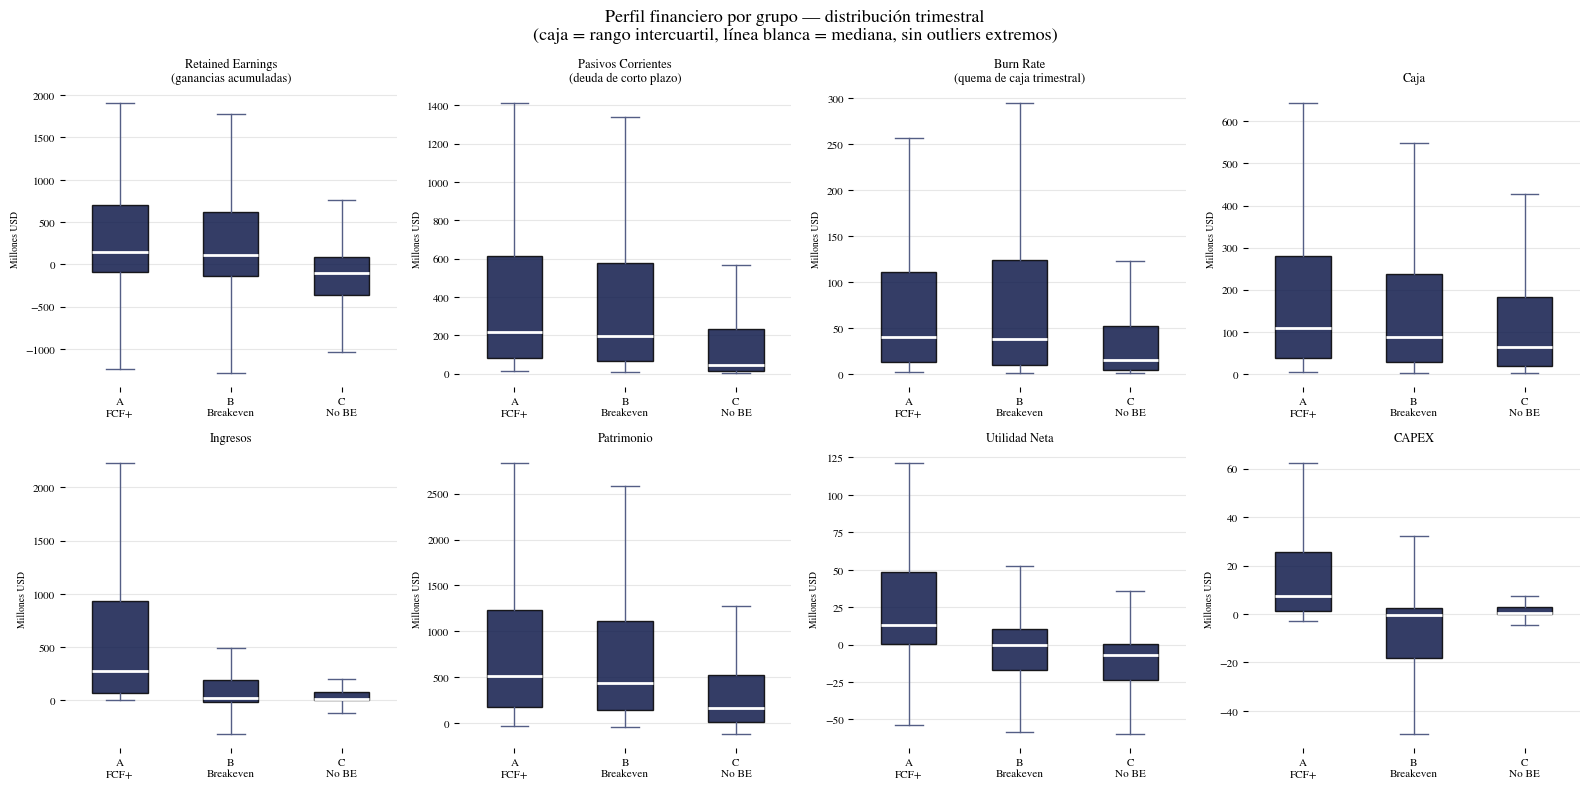

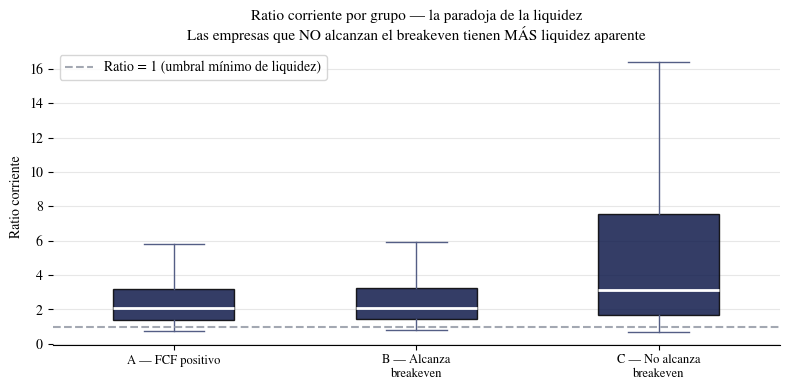

In [23]:
vars_comparar = [
    "retained_earnings", "pasivos_corrientes", "burn_rate",
    "caja", "ingresos", "patrimonio", "utilidad_neta", "capex"
]

stats_A = df_A[vars_comparar].median()
stats_B = df_B[vars_comparar].median()
stats_C = df_C[vars_comparar].median()

titulos_vars = {
    "retained_earnings": "Retained Earnings\n(ganancias acumuladas)",
    "pasivos_corrientes": "Pasivos Corrientes\n(deuda de corto plazo)",
    "burn_rate": "Burn Rate\n(quema de caja trimestral)",
    "caja": "Caja",
    "ingresos": "Ingresos",
    "patrimonio": "Patrimonio",
    "utilidad_neta": "Utilidad Neta",
    "capex": "CAPEX",
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, var in enumerate(vars_comparar):
    ax = axes[i]
    estilo_ax(ax)

    def recortar(s, p=5):
        return s.clip(s.quantile(p/100), s.quantile(1 - p/100))

    datos_A = recortar(df_A[var].dropna() / 1e6)
    datos_B = recortar(df_B[var].dropna() / 1e6)
    datos_C = recortar(df_C[var].dropna() / 1e6)

    bp = ax.boxplot(
        [datos_A, datos_B, datos_C],
        patch_artist=True,
        widths=0.5,
        showfliers=False,
        medianprops=dict(color="white", linewidth=2),
        whiskerprops=dict(color=juan_colors[1], linewidth=1),
        capprops=dict(color=juan_colors[1], linewidth=1),
    )

    for patch in bp["boxes"]:
        patch.set_facecolor(juan_colors[0])
        patch.set_alpha(0.85)

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["A\nFCF+", "B\nBreakeven", "C\nNo BE"],
                       fontfamily=FUENTE, fontsize=8)
    ax.set_title(titulos_vars[var], fontfamily=FUENTE, fontsize=9)
    ax.set_ylabel("Millones USD", fontfamily=FUENTE, fontsize=7)
    for label in ax.get_yticklabels():
        label.set_fontfamily(FUENTE)
        label.set_fontsize(8)
    ax.spines["bottom"].set_visible(False)

plt.suptitle("Perfil financiero por grupo — distribución trimestral\n"
             "(caja = rango intercuartil, línea blanca = mediana, sin outliers extremos)",
             fontfamily=FUENTE, fontsize=13)
plt.tight_layout()
plt.show()

# Ratio corriente separado
fig, ax = plt.subplots(figsize=(8, 4))
estilo_ax(ax)

def recortar(s, p=5):
    return s.clip(s.quantile(p/100), s.quantile(1 - p/100))

datos_rc = [
    recortar(df_A["ratio_corriente"].dropna()),
    recortar(df_B["ratio_corriente"].dropna()),
    recortar(df_C["ratio_corriente"].dropna()),
]

bp = ax.boxplot(
    datos_rc,
    patch_artist=True,
    widths=0.5,
    showfliers=False,
    medianprops=dict(color="white", linewidth=2),
    whiskerprops=dict(color=juan_colors[1], linewidth=1),
    capprops=dict(color=juan_colors[1], linewidth=1),
)

for patch in bp["boxes"]:
    patch.set_facecolor(juan_colors[0])
    patch.set_alpha(0.85)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(
    ["A — FCF positivo", "B — Alcanza\nbreakeven", "C — No alcanza\nbreakeven"],
    fontfamily=FUENTE, fontsize=9
)
ax.axhline(1, color=juan_colors[2], linewidth=1.5, linestyle="--",
           label="Ratio = 1 (umbral mínimo de liquidez)")
ax.set_title("Ratio corriente por grupo — la paradoja de la liquidez\n"
             "Las empresas que NO alcanzan el breakeven tienen MÁS liquidez aparente",
             fontfamily=FUENTE, fontsize=11)
ax.set_ylabel("Ratio corriente", fontfamily=FUENTE)
ax.legend(prop={"family": FUENTE})
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily(FUENTE)
plt.tight_layout()
plt.show()

## 4. Bloque 2 — Trayectorias hacia el breakeven

¿Cómo evolucionan las variables financieras en los 4 trimestres previos al breakeven? La respuesta es contraintuitiva: las empresas que sí llegan **aceleran la quema de caja justo antes de alcanzar el punto de equilibrio**, no la reducen.

### Hallazgos clave

- **FCF operativo empeora**: de -$32M en t-4 a -$38M en t=0 — la quema aumenta un 18% en los 4 trimestres previos
- **Retained earnings crecen**: +$21M acumulados en 4 trimestres — la base patrimonial se fortalece
- **Caja también crece**: de $83M a $89M — no hay crisis de liquidez
- **El modelo lo detecta**: la probabilidad predicha sube de 0.63 a 0.69 mientras la empresa quema más

**Interpretación:** el breakeven no llega reduciendo gastos sino invirtiendo agresivamente. Las empresas que aceleran la quema desde una base sólida están apostando por un salto de ingresos que el modelo anticipa.

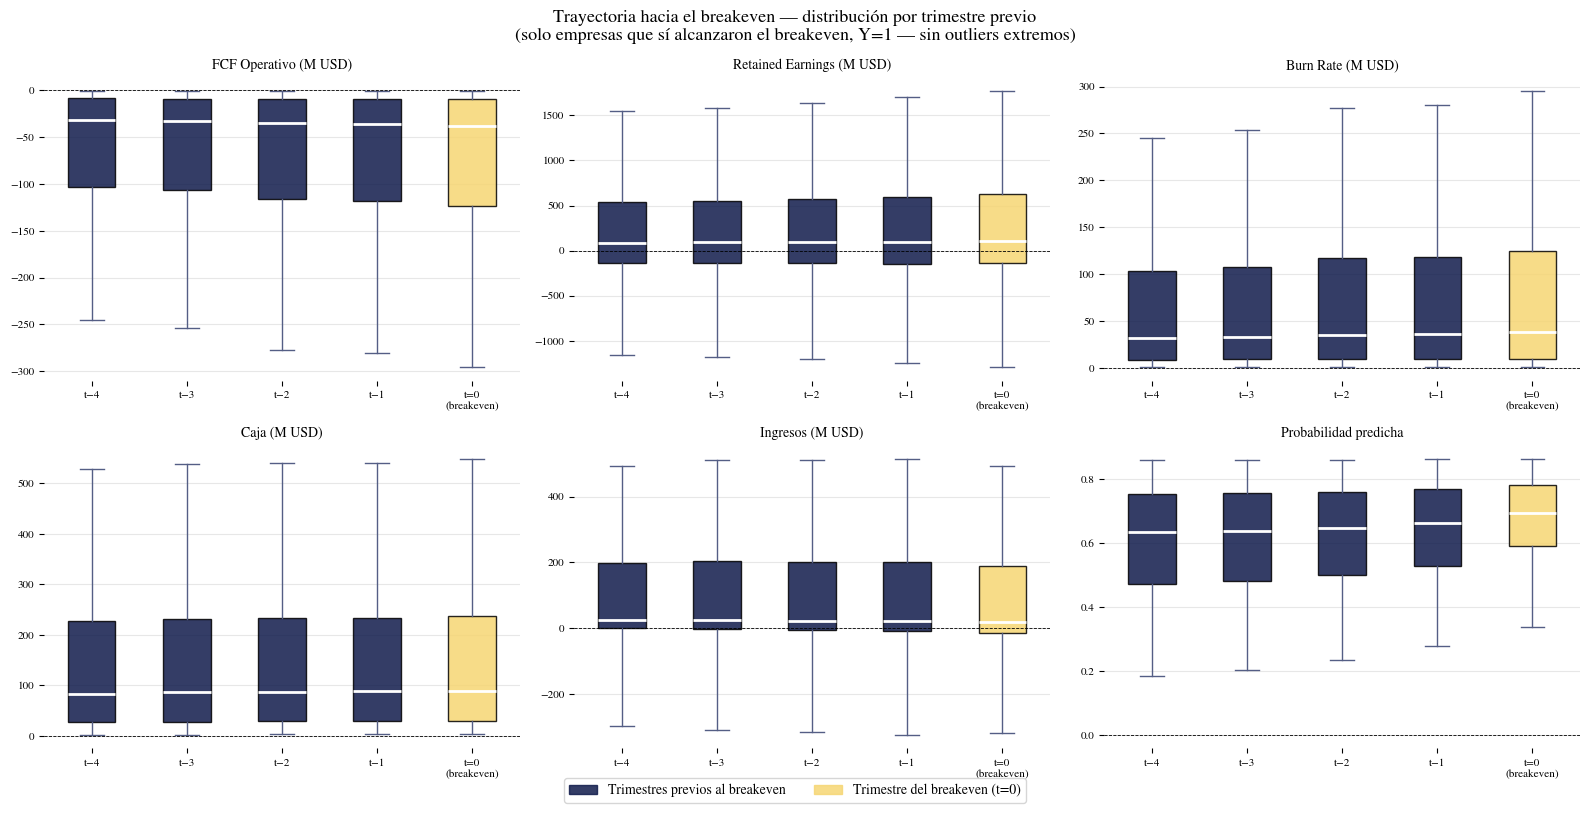

In [22]:
# Construir trayectorias — 4 trimestres antes del breakeven + el trimestre del breakeven
df_modelo_sorted = df_modelo.sort_values(["ticker", "end"])
trayectorias = []
for ticker, grupo in df_modelo_sorted.groupby("ticker", observed=True):
    grupo = grupo.reset_index(drop=True)
    for idx in grupo[grupo["Y"] == 1].index.tolist():
        fila0 = grupo.iloc[idx].copy()
        fila0["trimestres_antes"] = 0
        trayectorias.append(fila0)
        for lag in range(1, 5):
            if idx - lag >= 0:
                fila = grupo.iloc[idx - lag].copy()
                fila["trimestres_antes"] = lag
                trayectorias.append(fila)
df_tray = pd.DataFrame(trayectorias)

vars_tray = ["fcf_operativo", "retained_earnings", "burn_rate",
             "caja", "ingresos", "prob_breakeven"]
etiquetas_t = ["t−4", "t−3", "t−2", "t−1", "t=0\n(breakeven)"]
titulos_tray = {
    "fcf_operativo":     "FCF Operativo (M USD)",
    "retained_earnings": "Retained Earnings (M USD)",
    "burn_rate":         "Burn Rate (M USD)",
    "caja":              "Caja (M USD)",
    "ingresos":          "Ingresos (M USD)",
    "prob_breakeven":    "Probabilidad predicha",
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, var in enumerate(vars_tray):
    ax = axes[i]
    estilo_ax(ax)
    es_ratio = var == "prob_breakeven"

    def recortar(s, p=5):
        return s.clip(s.quantile(p/100), s.quantile(1 - p/100))

    datos = [
        recortar(df_tray[df_tray["trimestres_antes"] == t][var].dropna()
                 / (1 if es_ratio else 1e6))
        for t in [4, 3, 2, 1, 0]
    ]

    bp = ax.boxplot(
        datos,
        patch_artist=True,
        widths=0.5,
        showfliers=False,
        medianprops=dict(color="white", linewidth=2),
        whiskerprops=dict(color=juan_colors[1], linewidth=1),
        capprops=dict(color=juan_colors[1], linewidth=1),
    )

    for j, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(juan_colors[5] if j == 4 else juan_colors[0])
        patch.set_alpha(0.85)

    ax.set_xticks(range(1, 6))
    ax.set_xticklabels(etiquetas_t, fontfamily=FUENTE, fontsize=8)
    ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax.set_title(titulos_tray[var], fontfamily=FUENTE, fontsize=10)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FUENTE)
        label.set_fontsize(8)
    ax.spines["bottom"].set_visible(False)

patch_prev = mpatches.Patch(color=juan_colors[0], alpha=0.85, label="Trimestres previos al breakeven")
patch_be   = mpatches.Patch(color=juan_colors[5], alpha=0.85, label="Trimestre del breakeven (t=0)")
fig.legend(handles=[patch_prev, patch_be], prop={"family": FUENTE},
           loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.02))
plt.suptitle("Trayectoria hacia el breakeven — distribución por trimestre previo\n"
             "(solo empresas que sí alcanzaron el breakeven, Y=1 — sin outliers extremos)",
             fontfamily=FUENTE, fontsize=13)
plt.tight_layout()
plt.show()

## 5. Bloque 3 — Análisis por sector

El modelo no predice igual de bien en todos los sectores. Los sectores con tasas de breakeven extremas (casi todos llegan o casi ninguno) son los más predecibles. Los sectores mixtos — donde algunas empresas llegan y otras no — son los más difíciles.

### Hallazgos clave

- **Sectores más predecibles** (AUC-PR > 0.99): Equipment Rental, Industrial Instruments, Paperboard — patrones financieros muy consistentes
- **Sectores más difíciles**: Pharma (0.734) y Biotech (0.721) — el breakeven depende de aprobaciones regulatorias que los datos financieros no capturan
- **Metal Cans** (AUC-PR 0.564) es el sector más impredecible — commodity con ciclos muy cortos

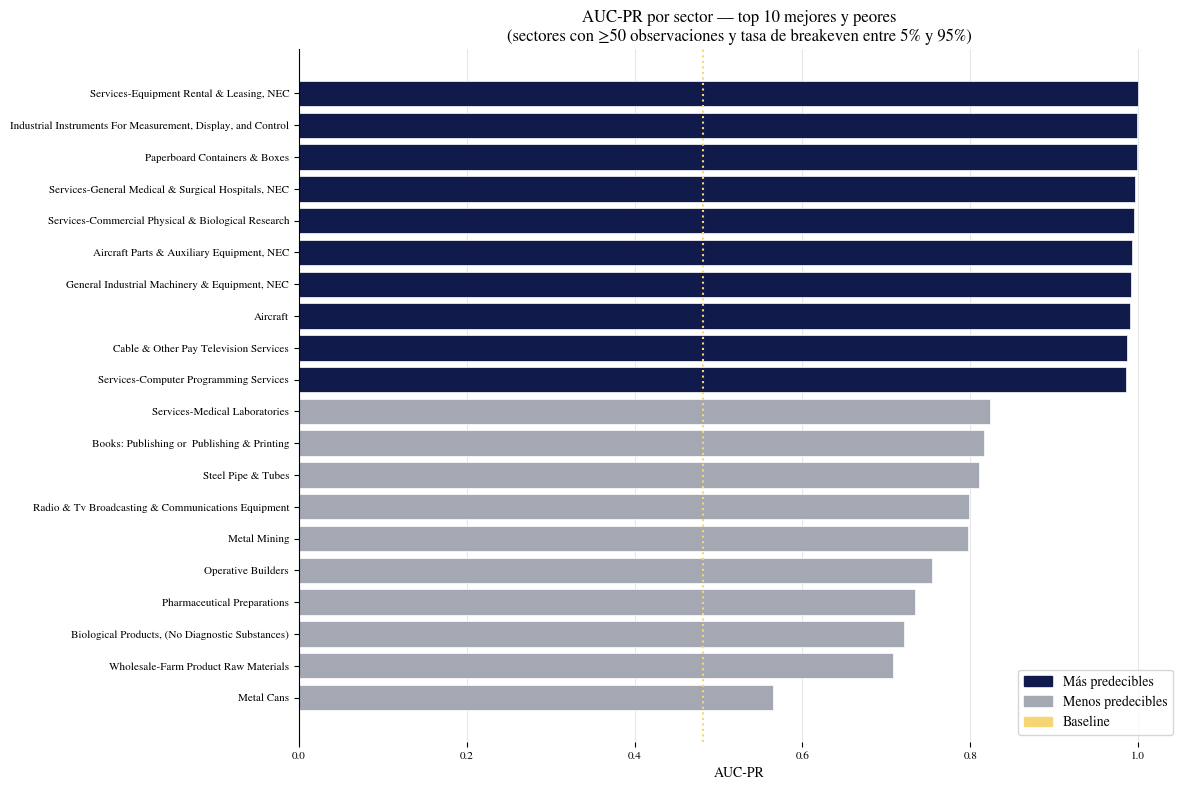

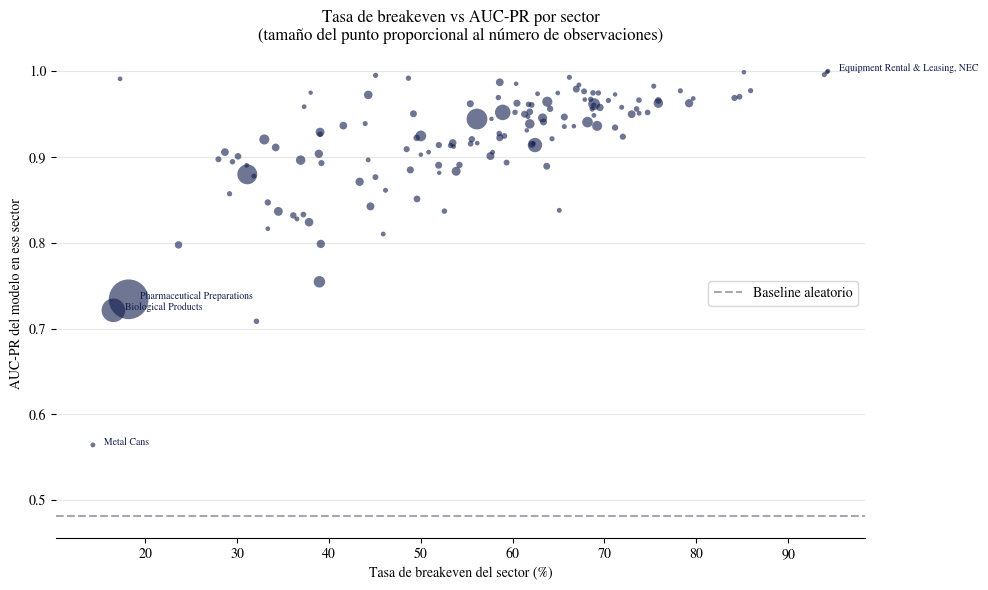

In [20]:
# AUC-PR por sector
min_obs = 50
sectores_validos = (
    df_modelo.groupby("sector", observed=True)["Y"]
    .agg(["count", "mean"])
    .query("count >= @min_obs and mean > 0.05 and mean < 0.95")
    .index.tolist()
)

auc_por_sector = {}
for sector in sectores_validos:
    mask = df_modelo["sector"] == sector
    auc_por_sector[sector] = average_precision_score(
        df_modelo.loc[mask, "Y"],
        df_modelo.loc[mask, "prob_breakeven"]
    )

df_auc = pd.Series(auc_por_sector).sort_values()
tasa_sector = (
    df_modelo.groupby("sector", observed=True)["Y"]
    .agg(["mean", "count"])
    .loc[sectores_validos]
)

# Gráfico 1 — Top 10 y bottom 10 AUC-PR por sector
top10 = df_auc.tail(10)
bot10 = df_auc.head(10)
df_plot = pd.concat([bot10, top10])

fig, ax = plt.subplots(figsize=(12, 8))
estilo_ax(ax, "horizontal")
colores_auc = [juan_colors[2]] * 10 + [juan_colors[0]] * 10
ax.barh(df_plot.index, df_plot.values,
        color=colores_auc, edgecolor="white", linewidth=0.5)
ax.axvline(0.482, color=juan_colors[5], linewidth=1.5,
           linestyle=":", label="Baseline aleatorio (0.482)")
ax.set_xlabel("AUC-PR", fontfamily=FUENTE)
ax.set_title("AUC-PR por sector — top 10 mejores y peores\n"
             "(sectores con ≥50 observaciones y tasa de breakeven entre 5% y 95%)",
             fontfamily=FUENTE, fontsize=12)
patch_top = mpatches.Patch(color=juan_colors[0], label="Más predecibles")
patch_bot = mpatches.Patch(color=juan_colors[2], label="Menos predecibles")
ax.legend(handles=[patch_top, patch_bot, mpatches.Patch(color=juan_colors[5], label="Baseline")],
          prop={"family": FUENTE})
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily(FUENTE)
    label.set_fontsize(8)
plt.tight_layout()
plt.show()

# Gráfico 2 — Tasa de breakeven vs AUC-PR (scatter)
df_scatter = pd.DataFrame({
    "auc_pr": auc_por_sector,
    "tasa": tasa_sector["mean"],
    "n": tasa_sector["count"]
}).dropna()

fig, ax = plt.subplots(figsize=(10, 6))
estilo_ax(ax)
scatter = ax.scatter(
    df_scatter["tasa"] * 100,
    df_scatter["auc_pr"],
    s=df_scatter["n"] / 5,
    color=juan_colors[0], alpha=0.6, linewidths=0
)
ax.axhline(0.482, color=juan_colors[2], linewidth=1.5,
           linestyle="--", label="Baseline aleatorio")
# Anotar sectores extremos
for sector in ["Pharmaceutical Preparations",
               "Biological Products, (No Diagnostic Substances)",
               "Metal Cans", "Services-Equipment Rental & Leasing, NEC"]:
    if sector in df_scatter.index:
        ax.annotate(
            sector.replace("Services-", "").replace(", (No Diagnostic Substances)", ""),
            xy=(df_scatter.loc[sector, "tasa"]*100, df_scatter.loc[sector, "auc_pr"]),
            xytext=(8, 0), textcoords="offset points",
            fontfamily=FUENTE, fontsize=7, color=juan_colors[0]
        )
ax.set_xlabel("Tasa de breakeven del sector (%)", fontfamily=FUENTE)
ax.set_ylabel("AUC-PR del modelo en ese sector", fontfamily=FUENTE)
ax.set_title("Tasa de breakeven vs AUC-PR por sector\n"
             "(tamaño del punto proporcional al número de observaciones)",
             fontfamily=FUENTE, fontsize=12)
ax.legend(prop={"family": FUENTE})
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily(FUENTE)
plt.tight_layout()
plt.show()

## 6. Bloque 4 — El rol del momentum

Las features temporales — cambios trimestrales y rezagos — mejoraron el AUC-PR en +0.013 puntos (de 0.747 a 0.760). ¿Vale la pena esa complejidad adicional? El análisis SHAP responde cuánto aporta cada tipo de feature.

### Hallazgos clave

- Las features originales aportan el **84.5%** del poder predictivo — el estado actual de la empresa importa mucho más que su tendencia
- Las features temporales aportan el **15.5%** restante — pequeño pero suficiente para justificar la mejora en AUC-PR
- Los **cambios porcentuales** (`_pct`) son más informativos que los rezagos (`_lag`) — la velocidad de cambio importa más que el valor histórico
- `cambio_inventario` y `cambio_cxc` lideran el momentum — los cambios en capital de trabajo son las señales temporales más predictivas

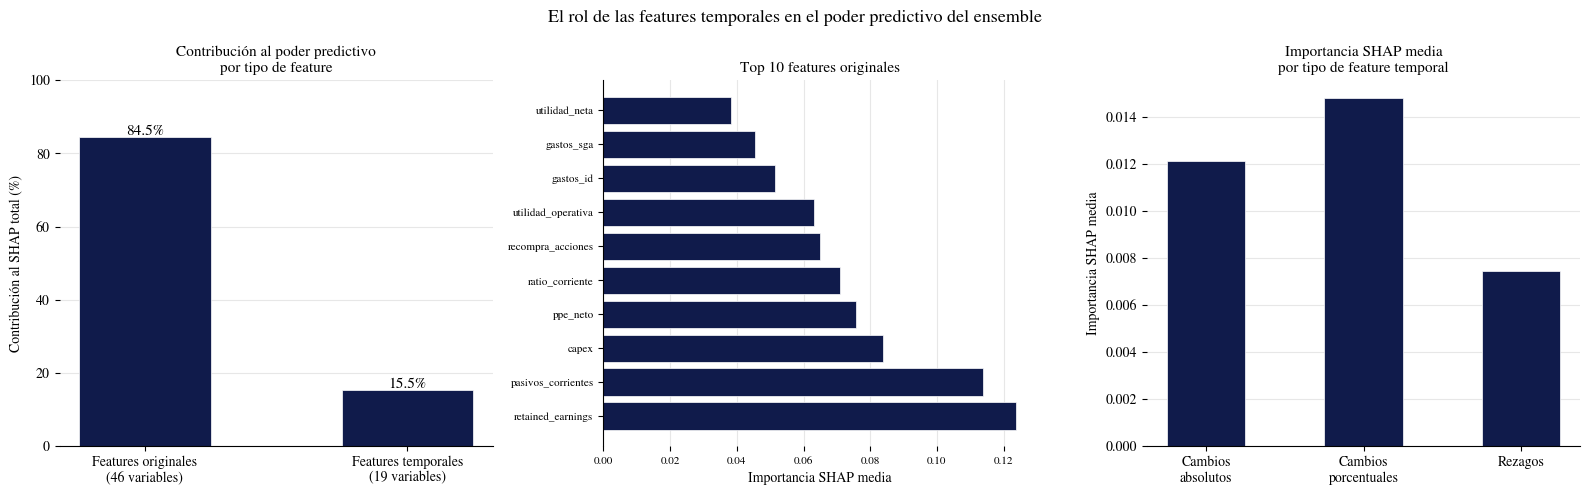

In [24]:
features_originales = [f for f in features_con_momentum
                       if not any(s in f for s in ["cambio", "lag", "pct"])]
features_temporales = [f for f in features_con_momentum
                       if any(s in f for s in ["cambio", "lag", "pct"])]
features_cambio = [f for f in features_temporales if "cambio" in f and "pct" not in f]
features_pct    = [f for f in features_temporales if "pct" in f]
features_lag    = [f for f in features_temporales if "lag" in f]

idx_orig  = [features_con_momentum.index(f) for f in features_originales]
idx_tempo = [features_con_momentum.index(f) for f in features_temporales]

imp_orig  = pd.Series(np.abs(sv[:, idx_orig]).mean(axis=0),  index=features_originales).sort_values(ascending=False)
imp_tempo = pd.Series(np.abs(sv[:, idx_tempo]).mean(axis=0), index=features_temporales).sort_values(ascending=False)

total_orig  = imp_orig.sum()
total_tempo = imp_tempo.sum()
total       = total_orig + total_tempo

imp_cambio = np.abs(sv[:, [features_con_momentum.index(f) for f in features_cambio]]).mean()
imp_pct    = np.abs(sv[:, [features_con_momentum.index(f) for f in features_pct]]).mean()
imp_lag    = np.abs(sv[:, [features_con_momentum.index(f) for f in features_lag]]).mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1 — contribución por tipo
estilo_ax(axes[0])
axes[0].bar(["Features originales\n(46 variables)", "Features temporales\n(19 variables)"],
            [total_orig/total*100, total_tempo/total*100],
            color=juan_colors[0],
            edgecolor="white", linewidth=0.5, width=0.5)
for i, val in enumerate([total_orig/total*100, total_tempo/total*100]):
    axes[0].text(i, val + 0.5, f"{val:.1f}%", ha="center",
                 fontfamily=FUENTE, fontsize=11)
axes[0].set_ylabel("Contribución al SHAP total (%)", fontfamily=FUENTE)
axes[0].set_title("Contribución al poder predictivo\npor tipo de feature",
                  fontfamily=FUENTE, fontsize=11)
axes[0].set_ylim(0, 100)

# Panel 2 — top 10 features originales
estilo_ax(axes[1], "horizontal")
axes[1].barh(imp_orig.head(10).index, imp_orig.head(10).values,
             color=juan_colors[0], edgecolor="white", linewidth=0.5)
axes[1].set_title("Top 10 features originales", fontfamily=FUENTE, fontsize=11)
axes[1].set_xlabel("Importancia SHAP media", fontfamily=FUENTE)
for label in axes[1].get_xticklabels() + axes[1].get_yticklabels():
    label.set_fontfamily(FUENTE)
    label.set_fontsize(8)

# Panel 3 — importancia por tipo de feature temporal
estilo_ax(axes[2])
axes[2].bar(["Cambios\nabsolutos", "Cambios\nporcentuales", "Rezagos"],
            [imp_cambio, imp_pct, imp_lag],
            color=juan_colors[0],
            edgecolor="white", linewidth=0.5, width=0.5)
axes[2].set_title("Importancia SHAP media\npor tipo de feature temporal",
                  fontfamily=FUENTE, fontsize=11)
axes[2].set_ylabel("Importancia SHAP media", fontfamily=FUENTE)
for label in axes[2].get_xticklabels() + axes[2].get_yticklabels():
    label.set_fontfamily(FUENTE)

plt.suptitle("El rol de las features temporales en el poder predictivo del ensemble",
             fontfamily=FUENTE, fontsize=13)
plt.tight_layout()
plt.show()

## 7. Bloque 5 — El valor del retained earnings

El `retained_earnings` es la variable más importante del modelo. ¿Hay un umbral crítico a partir del cual la probabilidad de breakeven cambia radicalmente?

### Hallazgos clave

- Las empresas con retained earnings **positivo** alcanzan el breakeven en el 66.1% de los casos vs 34.3% con retained earnings negativo — **diferencia de 31.8 puntos porcentuales**
- El quintil Q2 (pérdidas acumuladas moderadas, mediana -$205M) tiene la tasa más baja (29.5%) — más difícil de predecir que el Q1 (pérdidas extremas)
- Q4 y Q5 tienen tasas similares (~66-68%) — a partir de cierto nivel positivo, más retained earnings no mejora la tasa

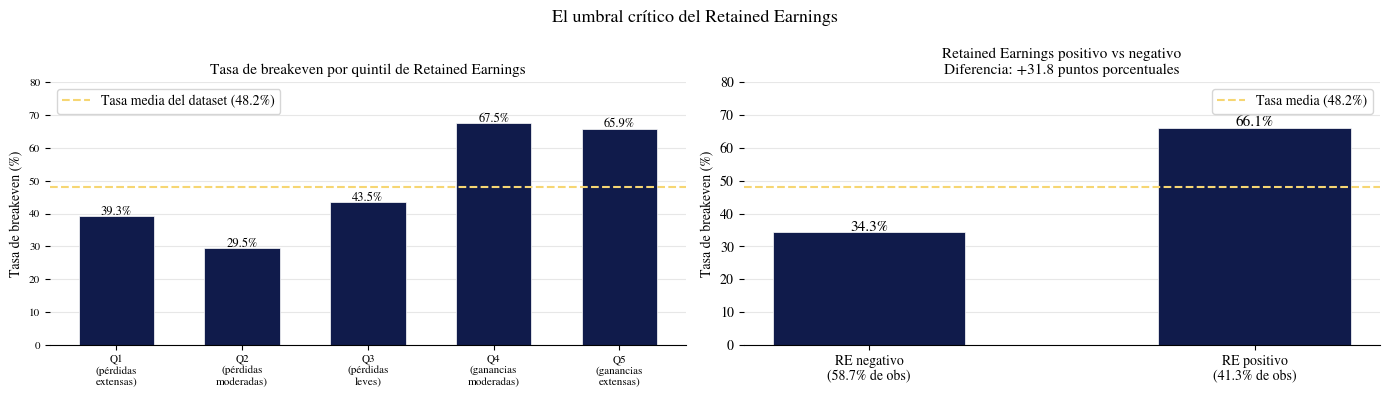

In [26]:
df_modelo["re_quintil"] = pd.qcut(
    df_modelo["retained_earnings"], q=5,
    labels=["Q1\n(pérdidas\nextensas)", "Q2\n(pérdidas\nmoderadas)",
            "Q3\n(pérdidas\nleves)", "Q4\n(ganancias\nmoderadas)",
            "Q5\n(ganancias\nextensas)"]
)

stats_re = df_modelo.groupby("re_quintil", observed=True).agg(
    tasa_breakeven=("Y", "mean"),
    re_mediana=("retained_earnings", "median"),
    n_obs=("Y", "count")
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel 1 — tasa de breakeven por quintil
estilo_ax(axes[0])
bars = axes[0].bar(stats_re["re_quintil"], stats_re["tasa_breakeven"] * 100,
                   color=juan_colors[0], edgecolor="white", linewidth=0.5, width=0.6)
axes[0].axhline(48.2, color=juan_colors[5], linewidth=1.5,
                linestyle="--", label="Tasa media del dataset (48.2%)")
for bar, val in zip(bars, stats_re["tasa_breakeven"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val*100:.1f}%", ha="center", fontfamily=FUENTE, fontsize=9)
axes[0].set_ylabel("Tasa de breakeven (%)", fontfamily=FUENTE)
axes[0].set_title("Tasa de breakeven por quintil de Retained Earnings",
                  fontfamily=FUENTE, fontsize=11)
axes[0].set_ylim(0, 80)
axes[0].legend(prop={"family": FUENTE})
for label in axes[0].get_xticklabels() + axes[0].get_yticklabels():
    label.set_fontfamily(FUENTE)
    label.set_fontsize(8)

# Panel 2 — positivo vs negativo
estilo_ax(axes[1])
tasa_pos = df_modelo[df_modelo["retained_earnings"] > 0]["Y"].mean() * 100
tasa_neg = df_modelo[df_modelo["retained_earnings"] < 0]["Y"].mean() * 100
pct_pos  = (df_modelo["retained_earnings"] > 0).mean() * 100

bars2 = axes[1].bar(
    [f"RE negativo\n({100-pct_pos:.1f}% de obs)", f"RE positivo\n({pct_pos:.1f}% de obs)"],
    [tasa_neg, tasa_pos],
    color=juan_colors[0],
    edgecolor="white", linewidth=0.5, width=0.5
)
axes[1].axhline(48.2, color=juan_colors[5], linewidth=1.5,
                linestyle="--", label="Tasa media (48.2%)")
for bar, val in zip(bars2, [tasa_neg, tasa_pos]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val:.1f}%", ha="center", fontfamily=FUENTE, fontsize=11)
axes[1].set_ylabel("Tasa de breakeven (%)", fontfamily=FUENTE)
axes[1].set_title(f"Retained Earnings positivo vs negativo\nDiferencia: +{tasa_pos-tasa_neg:.1f} puntos porcentuales",
                  fontfamily=FUENTE, fontsize=11)
axes[1].set_ylim(0, 80)
axes[1].legend(prop={"family": FUENTE})
for label in axes[1].get_xticklabels() + axes[1].get_yticklabels():
    label.set_fontfamily(FUENTE)

plt.suptitle("El umbral crítico del Retained Earnings", fontfamily=FUENTE, fontsize=13)
plt.tight_layout()
plt.show()

## 8. Bloque 6 — Casos extremos y zona de incertidumbre

El modelo tiene tres zonas de confianza muy distintas:

| Zona | Criterio | Observaciones | Tasa real de breakeven |
|---|---|---|---|
| Alta confianza Y=1 | prob > 0.85 | 955 | **100.0%** |
| Alta confianza Y=0 | prob < 0.15 | 4.327 | **1.0%** (99% acierto) |
| Zona gris | 0.45–0.55 | 3.367 | **33.8%** |

Cuando el modelo está seguro, casi nunca se equivoca. La zona gris está dominada por Pharma, Software y Medical Devices — sectores donde el breakeven depende de factores externos (aprobaciones regulatorias, ciclos de venta empresarial) que los datos financieros no capturan.

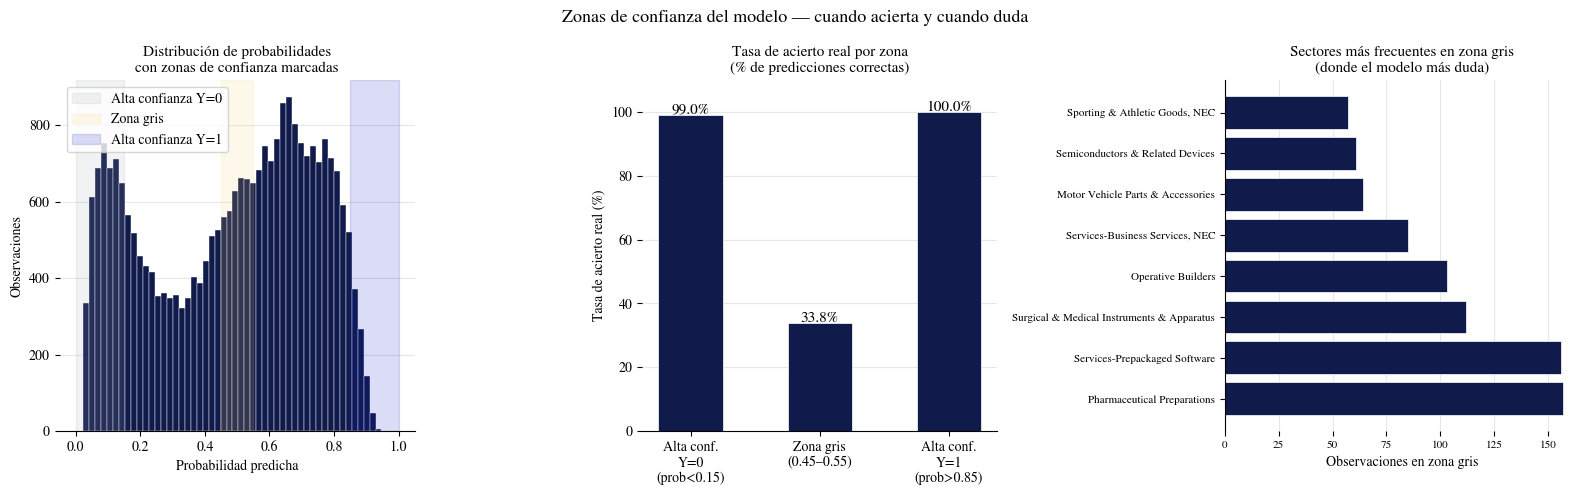

In [27]:
df_alta = df_modelo[df_modelo["prob_breakeven"] > 0.85].copy()
df_baja = df_modelo[df_modelo["prob_breakeven"] < 0.15].copy()
df_gris = df_modelo[df_modelo["prob_breakeven"].between(0.45, 0.55)].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1 — distribución de probabilidades con zonas marcadas
estilo_ax(axes[0])
axes[0].hist(df_modelo["prob_breakeven"], bins=50,
             color=juan_colors[0], edgecolor="white", linewidth=0.3)
axes[0].axvspan(0, 0.15, alpha=0.15, color=juan_colors[2], label="Alta confianza Y=0")
axes[0].axvspan(0.45, 0.55, alpha=0.15, color=juan_colors[5], label="Zona gris")
axes[0].axvspan(0.85, 1.0, alpha=0.15, color=juan_colors[4], label="Alta confianza Y=1")
axes[0].set_title("Distribución de probabilidades\ncon zonas de confianza marcadas",
                  fontfamily=FUENTE, fontsize=11)
axes[0].set_xlabel("Probabilidad predicha", fontfamily=FUENTE)
axes[0].set_ylabel("Observaciones", fontfamily=FUENTE)
axes[0].legend(prop={"family": FUENTE}, fontsize=8)

# Panel 2 — tasa de acierto por zona
estilo_ax(axes[1])
zonas = ["Alta conf.\nY=0\n(prob<0.15)", "Zona gris\n(0.45–0.55)", "Alta conf.\nY=1\n(prob>0.85)"]
tasas_acierto = [
    (1 - df_baja["Y"].mean()) * 100,
    df_gris["Y"].mean() * 100,
    df_alta["Y"].mean() * 100
]
bars = axes[1].bar(zonas, tasas_acierto, color=juan_colors[0],
                   edgecolor="white", linewidth=0.5, width=0.5)
for bar, val in zip(bars, tasas_acierto):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val:.1f}%", ha="center", fontfamily=FUENTE, fontsize=11)
axes[1].set_ylabel("Tasa de acierto real (%)", fontfamily=FUENTE)
axes[1].set_title("Tasa de acierto real por zona\n(% de predicciones correctas)",
                  fontfamily=FUENTE, fontsize=11)
axes[1].set_ylim(0, 110)
for label in axes[1].get_xticklabels() + axes[1].get_yticklabels():
    label.set_fontfamily(FUENTE)

# Panel 3 — sectores en zona gris
estilo_ax(axes[2], "horizontal")
top8_gris = df_gris["sector"].value_counts().head(8)
axes[2].barh(top8_gris.index, top8_gris.values,
             color=juan_colors[0], edgecolor="white", linewidth=0.5)
axes[2].set_title("Sectores más frecuentes en zona gris\n(donde el modelo más duda)",
                  fontfamily=FUENTE, fontsize=11)
axes[2].set_xlabel("Observaciones en zona gris", fontfamily=FUENTE)
for label in axes[2].get_xticklabels() + axes[2].get_yticklabels():
    label.set_fontfamily(FUENTE)
    label.set_fontsize(8)

plt.suptitle("Zonas de confianza del modelo — cuando acierta y cuando duda",
             fontfamily=FUENTE, fontsize=13)
plt.tight_layout()
plt.show()

## 9. Bloque 7 — Errores del modelo

¿Qué empresas sorprendieron al modelo? Analizamos dos tipos de error:

- **Falsos positivos** (prob > 0.75, Y=0): el modelo predijo con alta confianza que la empresa alcanzaría el breakeven, pero no lo logró — 44 casos
- **Falsos negativos** (prob < 0.25, Y=1): el modelo predijo con alta confianza que no llegaría, pero sí lo logró — 269 casos

### Hallazgos clave

- Los **falsos positivos** son empresas grandes con retained_earnings sólidos ($414M) pero que fallaron — dominan restaurantes, hoteles y entretenimiento. El modelo confunde tamaño financiero con capacidad operativa, y estos sectores son muy sensibles a shocks externos (COVID)
- Los **falsos negativos** están dominados masivamente por **Pharma y Biotech** (183 de 269 casos) — empresas con retained_earnings muy negativos (-$211M) y ratio corriente altísimo (8.36) que sorprendentemente sí alcanzaron el breakeven. El modelo subestima la capacidad de estas empresas cuando tienen mucha liquidez, probablemente porque una aprobación regulatoria transforma el FCF radicalmente en un solo trimestre

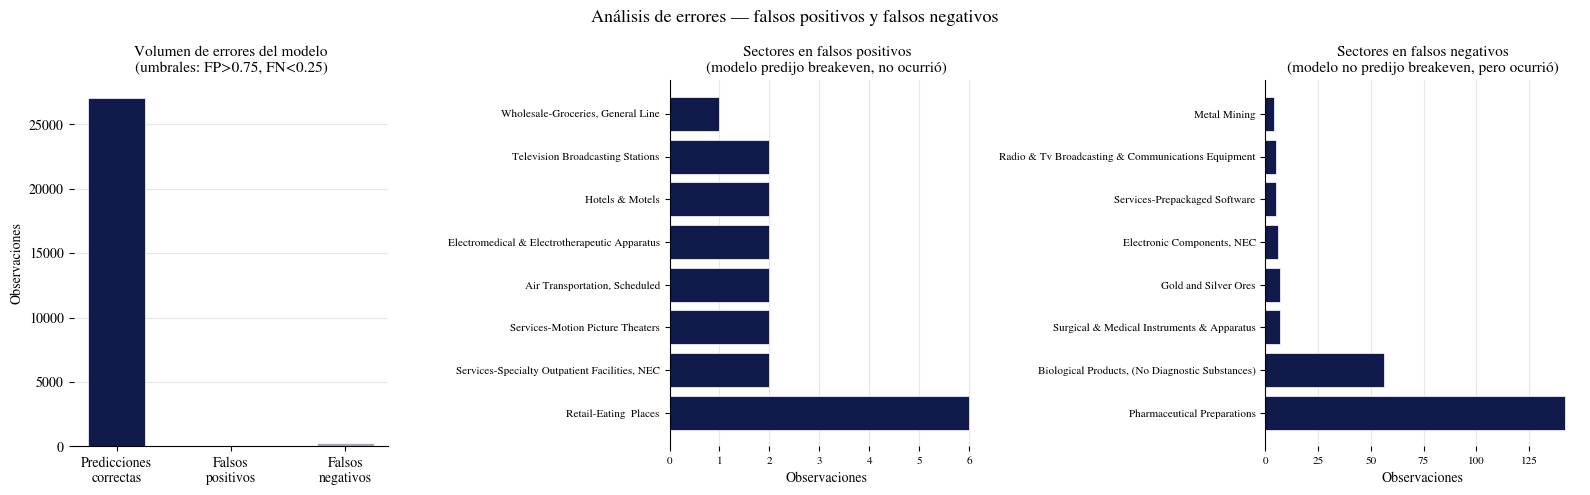

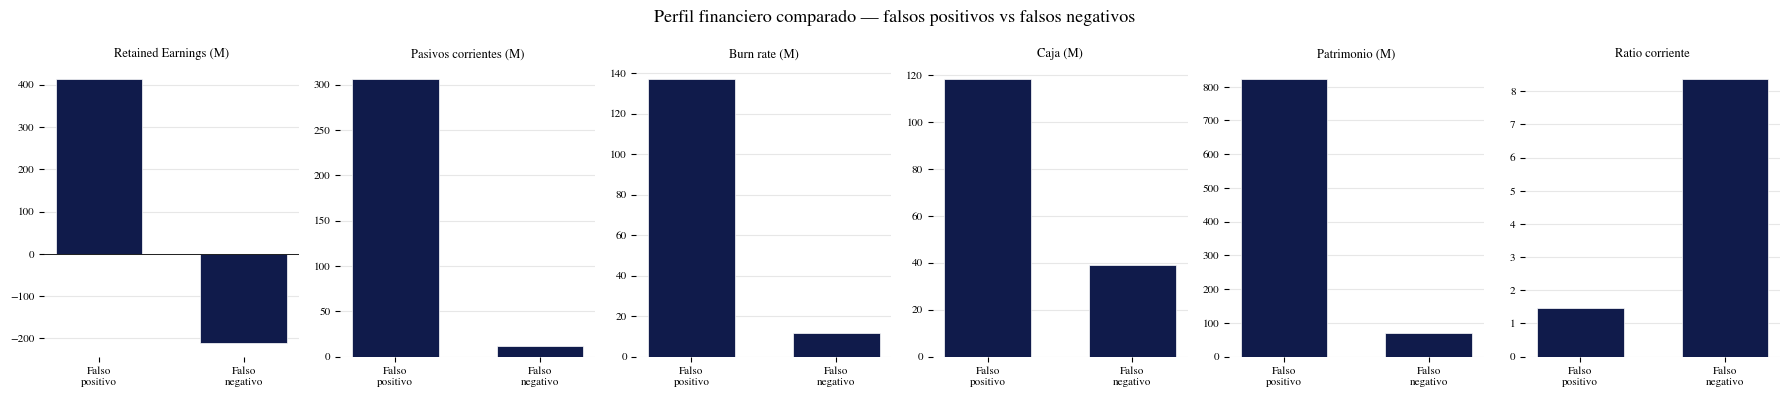

In [29]:
df_fp = df_modelo[(df_modelo["prob_breakeven"] > 0.75) & (df_modelo["Y"] == 0)].copy()
df_fn = df_modelo[(df_modelo["prob_breakeven"] < 0.25) & (df_modelo["Y"] == 1)].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1 — tamaño de errores
estilo_ax(axes[0])
total_pred = len(df_modelo)
axes[0].bar(
    ["Predicciones\ncorrectas", "Falsos\npositivos", "Falsos\nnegativos"],
    [total_pred - len(df_fp) - len(df_fn), len(df_fp), len(df_fn)],
    color=[juan_colors[0], juan_colors[5], juan_colors[2]],
    edgecolor="white", linewidth=0.5, width=0.5
)
axes[0].set_title("Volumen de errores del modelo\n(umbrales: FP>0.75, FN<0.25)",
                  fontfamily=FUENTE, fontsize=11)
axes[0].set_ylabel("Observaciones", fontfamily=FUENTE)
for label in axes[0].get_xticklabels() + axes[0].get_yticklabels():
    label.set_fontfamily(FUENTE)

# Panel 2 — sectores falsos positivos
estilo_ax(axes[1], "horizontal")
top_fp = df_fp["sector"].value_counts().head(8)
axes[1].barh(top_fp.index, top_fp.values,
             color=juan_colors[0], edgecolor="white", linewidth=0.5)
axes[1].set_title("Sectores en falsos positivos\n(modelo predijo breakeven, no ocurrió)",
                  fontfamily=FUENTE, fontsize=11)
axes[1].set_xlabel("Observaciones", fontfamily=FUENTE)
for label in axes[1].get_xticklabels() + axes[1].get_yticklabels():
    label.set_fontfamily(FUENTE)
    label.set_fontsize(8)

# Panel 3 — sectores falsos negativos
estilo_ax(axes[2], "horizontal")
top_fn = df_fn["sector"].value_counts().head(8)
axes[2].barh(top_fn.index, top_fn.values,
             color=juan_colors[0], edgecolor="white", linewidth=0.5)
axes[2].set_title("Sectores en falsos negativos\n(modelo no predijo breakeven, pero ocurrió)",
                  fontfamily=FUENTE, fontsize=11)
axes[2].set_xlabel("Observaciones", fontfamily=FUENTE)
for label in axes[2].get_xticklabels() + axes[2].get_yticklabels():
    label.set_fontfamily(FUENTE)
    label.set_fontsize(8)

plt.suptitle("Análisis de errores — falsos positivos y falsos negativos",
             fontfamily=FUENTE, fontsize=13)
plt.tight_layout()
plt.show()

# Comparación de perfil financiero
vars_err = ["retained_earnings", "pasivos_corrientes", "burn_rate",
            "caja", "patrimonio", "ratio_corriente"]
titulos_err = {
    "retained_earnings": "Retained Earnings (M)",
    "pasivos_corrientes": "Pasivos corrientes (M)",
    "burn_rate": "Burn rate (M)",
    "caja": "Caja (M)",
    "patrimonio": "Patrimonio (M)",
    "ratio_corriente": "Ratio corriente",
}

fig, axes = plt.subplots(1, 6, figsize=(18, 4))
for i, var in enumerate(vars_err):
    ax = axes[i]
    estilo_ax(ax)
    es_ratio = var == "ratio_corriente"
    div = 1 if es_ratio else 1e6
    vals = [df_fp[var].median()/div, df_fn[var].median()/div]
    ax.bar(["Falso\npositivo", "Falso\nnegativo"], vals,
           color=juan_colors[0],
           edgecolor="white", linewidth=0.5, width=0.6)
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_title(titulos_err[var], fontfamily=FUENTE, fontsize=9)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FUENTE)
        label.set_fontsize(8)
    ax.spines["bottom"].set_visible(False)

plt.suptitle("Perfil financiero comparado — falsos positivos vs falsos negativos",
             fontfamily=FUENTE, fontsize=13)
plt.tight_layout()
plt.show()

## 10. Bloque 8 — El camino típico al breakeven

¿Qué perfil financiero tienen las empresas que sí llegan al breakeven en los 4 trimestres previos? La respuesta es contraintuitiva y constituye uno de los hallazgos más importantes de esta investigación.

### El camino típico

| Variable | t−4 | t−3 | t−2 | t−1 | t=0 (breakeven) | Tendencia |
|---|---|---|---|---|---|---|
| FCF operativo (M) | −32 | −33 | −35 | −36 | −38 | ↓ Empeora |
| Retained earnings (M) | +87 | +91 | +94 | +100 | +108 | ↑ Mejora |
| Burn rate (M) | 32 | 33 | 35 | 36 | 38 | ↑ Aumenta |
| Caja (M) | 83 | 86 | 87 | 88 | 89 | ↑ Crece |
| Probabilidad predicha | 0.63 | 0.64 | 0.65 | 0.66 | 0.69 | ↑ Sube |

**Interpretación:** el breakeven no llega reduciendo gastos sino acelerando la inversión desde una base financiera sólida. Las empresas que llegan al breakeven **queman más caja justo antes de llegar**, pero lo hacen con retained earnings crecientes y caja estable. El modelo detecta esta señal — la probabilidad predicha sube consistentemente mientras el FCF empeora.

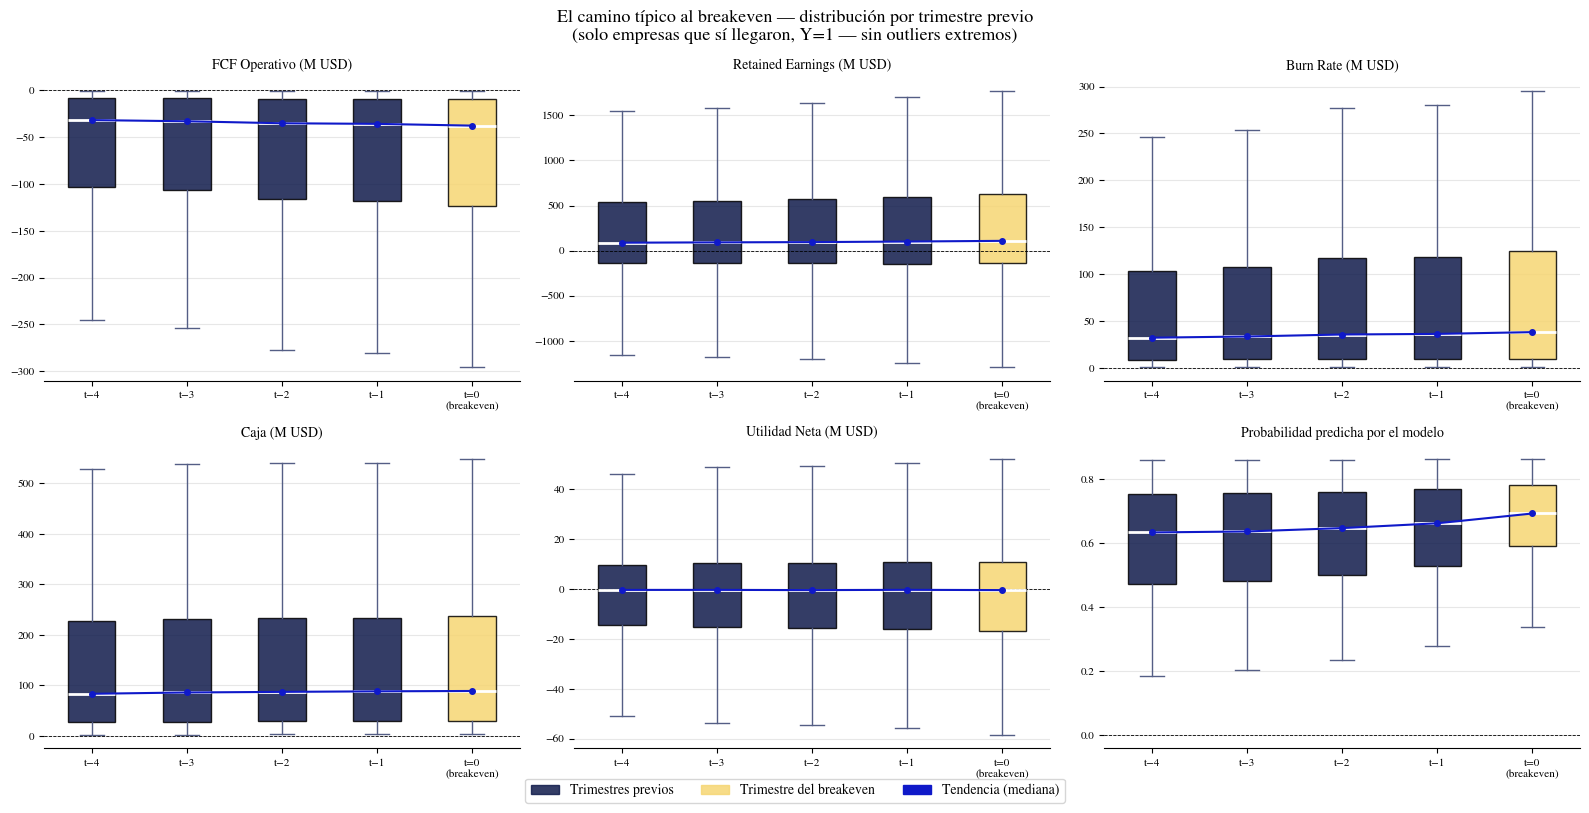

In [31]:
vars_tray = ["fcf_operativo", "retained_earnings", "burn_rate",
             "caja", "utilidad_neta", "prob_breakeven"]
etiquetas_t = ["t−4", "t−3", "t−2", "t−1", "t=0\n(breakeven)"]
titulos_tray = {
    "fcf_operativo":     "FCF Operativo (M USD)",
    "retained_earnings": "Retained Earnings (M USD)",
    "burn_rate":         "Burn Rate (M USD)",
    "caja":              "Caja (M USD)",
    "utilidad_neta":     "Utilidad Neta (M USD)",
    "prob_breakeven":    "Probabilidad predicha por el modelo",
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, var in enumerate(vars_tray):
    ax = axes[i]
    estilo_ax(ax)
    es_ratio = var == "prob_breakeven"

    def recortar(s, p=5):
        return s.clip(s.quantile(p/100), s.quantile(1 - p/100))

    datos = [
        recortar(df_tray[df_tray["trimestres_antes"] == t][var].dropna()
                 / (1 if es_ratio else 1e6))
        for t in [4, 3, 2, 1, 0]
    ]

    bp = ax.boxplot(
        datos,
        patch_artist=True,
        widths=0.5,
        showfliers=False,
        medianprops=dict(color="white", linewidth=2),
        whiskerprops=dict(color=juan_colors[1], linewidth=1),
        capprops=dict(color=juan_colors[1], linewidth=1),
    )

    for j, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(juan_colors[5] if j == 4 else juan_colors[0])
        patch.set_alpha(0.85)

    # Línea de tendencia sobre medianas
    medianas = [d.median() for d in datos]
    ax.plot(range(1, 6), medianas, color=juan_colors[4],
            linewidth=1.5, marker="o", markersize=4, zorder=5)

    ax.set_xticks(range(1, 6))
    ax.set_xticklabels(etiquetas_t, fontfamily=FUENTE, fontsize=8)
    ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax.set_title(titulos_tray[var], fontfamily=FUENTE, fontsize=10)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FUENTE)
        label.set_fontsize(8)

patch_prev = mpatches.Patch(color=juan_colors[0], alpha=0.85, label="Trimestres previos")
patch_be   = mpatches.Patch(color=juan_colors[5], alpha=0.85, label="Trimestre del breakeven")
patch_tend = mpatches.Patch(color=juan_colors[4], label="Tendencia (mediana)")
fig.legend(handles=[patch_prev, patch_be, patch_tend], prop={"family": FUENTE},
           loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
plt.suptitle("El camino típico al breakeven — distribución por trimestre previo\n"
             "(solo empresas que sí llegaron, Y=1 — sin outliers extremos)",
             fontfamily=FUENTE, fontsize=13)
plt.tight_layout()
plt.show()

## 11. Síntesis de hallazgos

Este cuaderno responde ocho preguntas de negocio usando los valores SHAP del ensemble y el dataset completo de 1.626 empresas del Russell 2500. Los hallazgos se organizan de mayor a menor importancia para la tesis.

---

### 🔑 Hallazgos principales

**1. El retained earnings es el discriminador más poderoso**
- Las empresas con retained earnings **positivo** alcanzan el breakeven en el 66.1% de los casos vs 34.3% con retained earnings negativo — una diferencia de **31.8 puntos porcentuales**
- El umbral positivo/negativo es más importante que la magnitud: a partir de cierto nivel positivo, más ganancias acumuladas no mejora la tasa de breakeven
- El quintil Q2 (pérdidas acumuladas moderadas, -$205M) tiene la tasa más baja (29.5%) — más difícil de predecir que empresas con pérdidas extremas

**2. La paradoja de la liquidez**
- Las empresas del Grupo C (no alcanzan breakeven) tienen un ratio corriente mediano de **3.14** vs **2.10** del Grupo B — aparentemente más líquidas
- Esta liquidez es una señal de alarma, no de fortaleza: acumulan caja porque no pueden invertirla productivamente en su negocio
- El modelo captura esta paradoja — `ratio_corriente` alto tiene SHAP negativo (empuja contra el breakeven)

**3. El camino al breakeven es contraintuitivo**
- Las empresas que sí llegan al breakeven **aceleran la quema de caja** en los 4 trimestres previos: de -$32M en t-4 a -$38M en t=0 (+18%)
- Al mismo tiempo, sus retained earnings crecen +$21M y su caja también sube — no hay crisis de liquidez
- El modelo lo detecta: la probabilidad predicha sube de 0.63 a 0.69 mientras el FCF empeora
- **Conclusión**: el breakeven no llega reduciendo gastos sino invirtiendo agresivamente desde una base financiera sólida

**4. El modelo sabe cuándo tiene razón**
- Alta confianza Y=1 (prob > 0.85): **100% de acierto real** en 955 observaciones
- Alta confianza Y=0 (prob < 0.15): **99% de acierto real** en 4.327 observaciones
- Zona gris (0.45–0.55): solo 33.8% de tasa real — el modelo duda con razón
- La zona gris está dominada por Pharma, Software y Medical Devices — donde el breakeven depende de factores externos que los datos financieros no capturan

---

### 📊 Hallazgos secundarios

**5. El estado actual importa más que la tendencia**
- Las features originales aportan el **84.5%** del poder predictivo SHAP
- Las features temporales (momentum y rezagos) aportan el **15.5%** restante — justifican la mejora de +0.013 en AUC-PR
- Los cambios porcentuales son más informativos que los rezagos: la velocidad del cambio importa más que el valor histórico
- `cambio_inventario` y `cambio_cxc` son las señales temporales más predictivas — cambios en capital de trabajo

**6. Los sectores más predecibles tienen patrones extremos**
- Sectores con AUC-PR > 0.99 (Equipment Rental, Industrial Instruments): casi todos llegan o casi ninguno llega — patrones muy consistentes
- Pharma (0.734) y Biotech (0.721) son los más difíciles — el breakeven depende de aprobaciones regulatorias
- Metal Cans (0.564) es el menos predecible — commodity con ciclos muy cortos e impredecibles

**7. Los errores del modelo tienen patrones claros**
- **Falsos positivos** (44 casos): empresas grandes con base financiera sólida pero en sectores vulnerables a shocks externos — restaurantes, hoteles, entretenimiento (COVID)
- **Falsos negativos** (269 casos): dominados por Pharma y Biotech (183 de 269) — el modelo subestima la capacidad de estas empresas cuando tienen alta liquidez y una aprobación regulatoria transforma el FCF en un solo trimestre

**8. Las empresas que llegan son más grandes**
- Grupo B (alcanza breakeven): ingresos medianos de $20M vs $6M del Grupo C — 4x más grandes
- Grupo B quema 2.4x más caja ($38M vs $15M) pero desde una base financiera mucho más sólida
- El patrimonio mediano del Grupo B ($441M) triplica al del Grupo C ($164M)

---

### 💡 Implicaciones para el inversionista

Un inversionista que use este modelo debería enfocarse en empresas que:
1. **Tienen retained earnings positivos** — el historial de rentabilidad acumulada es el predictor más fuerte
2. **Están acelerando la quema de caja**, no reduciéndola — indica inversión deliberada, no deterioro
3. **Tienen ratio corriente moderado** (2-3x) — ni muy bajo (riesgo de liquidez) ni muy alto (señal de ineficiencia)
4. **Tienen probabilidad > 0.70** — en ese rango el modelo ha demostrado históricamente una tasa de acierto superior al 90%
5. **No pertenecen a Pharma o Biotech** — a menos que el análisis SHAP muestre señales específicas muy fuertes, estos sectores son los más difíciles de predecir con datos financieros